# AI-Driven Housing Affordability Forecasting in New York City
## IEEE-Standard Upgraded Analysis | NTA-Level Panel Dataset (2012–2022)

---

| Item | Detail |
|---|---|
| **Author** | Azizur Rahman |
| **Institution** | Indiana Wesleyan University — Dept. of Computer Science & AI |
| **Dataset** | 2,512 NTA-year observations · 239 Neighborhoods · 4 Boroughs |
| **Target** | `rent_burden_50plus_pct` — Share of renters paying ≥50% of income on housing |
| **Best Model** | LightGBM — Test R²=0.9214, RMSE=0.036 |
| **Notebook** | Run cells top-to-bottom. Uses `n_estimators=50` — will not freeze. |

---

## Section 1 — Setup & Imports

In [4]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import copy

try:
    import lightgbm as lgb
    LGB = True
    print(f"LightGBM {lgb.__version__} ready")
except ImportError:
    LGB = False
    print("LightGBM not found — RF + XGBoost only")

try:
    import shap
    SHAP = True
    print(f"SHAP {shap.__version__} ready")
except ImportError:
    SHAP = False
    print("SHAP not found — using built-in feature importance")

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
sns.set_palette("tab10")

BORO_COLOR = {
    "Bronx":     "#E63946",
    "Brooklyn":  "#457B9D",
    "Manhattan": "#2A9D8F",
    "Queens":    "#E9C46A",
}
COLORS = list(BORO_COLOR.values())
BOROS  = ["Bronx", "Brooklyn", "Manhattan", "Queens"]

print("\nAll libraries loaded successfully.")

LightGBM 4.6.0 ready
SHAP 0.46.0 ready

All libraries loaded successfully.


## Section 2 — Data Loading

In [6]:
df = pd.read_csv("expanded_data/nta_panel_final.csv")

print("=" * 55)
print(f"  Rows × Cols  : {df.shape[0]:,} × {df.shape[1]}")
print(f"  NTAs         : {df.nta_code.nunique()}")
print(f"  Boroughs     : {sorted(df.borough_name.dropna().unique().tolist())}")
print(f"  Years        : {int(df.year.min())} – {int(df.year.max())}")
print("=" * 55)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing values per column (top 10):")
print(missing.head(10).to_string())

df.head(3)

  Rows × Cols  : 2,512 × 49
  NTAs         : 239
  Boroughs     : ['Bronx', 'Brooklyn', 'Manhattan', 'Queens']
  Years        : 2012 – 2022

Missing values per column (top 10):
zillow_rent_index            672
renter_median_income_lag1    671
median_gross_rent_lag1       662
median_hh_income_lag1        650
rent_growth_yoy              619
income_growth_yoy            593
renter_median_income         488
renter_income_ratio          488
income_gap                   488
median_contract_rent         481


,nta_code,nta_name,borough_name,year,renter_hh_total,rent_burden_30_34,rent_burden_35_39,rent_burden_40_49,rent_burden_50plus,total_occupied_units,...,covid_year,borough_code,median_hh_income_lag1,renter_median_income_lag1,unemployment_rate_lag1,rent_burden_30plus_pct_lag1,vacancy_rate_lag1,median_gross_rent_lag1,income_growth_yoy,rent_growth_yoy
0,BK0101,Greenpoint,Brooklyn,2012,9672.0,826.0,297.0,829.0,2229.0,11987.0,...,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BK0101,Greenpoint,Brooklyn,2013,9742.0,809.0,325.0,718.0,2294.0,12029.0,...,0,2,63347.536222,62110.063283,0.066695,0.432279,0.134950,1357.446791,0.051789,0.093401
2,BK0101,Greenpoint,Brooklyn,2014,9618.0,795.0,328.0,626.0,2328.0,12236.0,...,0,2,66628.258337,64385.282590,0.064537,0.425580,0.130978,1484.233478,0.030609,0.061706


## Section 3 — Descriptive Statistics

> These values are computed live from the dataset and match the updated IEEE paper Table III.

In [8]:
stat_cols = [
    "rent_burden_50plus_pct", "rent_burden_30plus_pct",
    "median_hh_income", "median_gross_rent", "median_contract_rent",
    "renter_income_ratio", "vacancy_rate", "unemployment_rate",
    "gini_coefficient", "severe_crowding_rate",
]
avail = [c for c in stat_cols if c in df.columns]

rows = []
for c in avail:
    s = df[c].dropna()
    rows.append({
        "Variable"  : c,
        "n"         : len(s),
        "Mean"      : round(s.mean(), 4),
        "Median"    : round(s.median(), 4),
        "Std Dev"   : round(s.std(), 4),
        "Min"       : round(s.min(), 4),
        "Max"       : round(s.max(), 4),
        "Skewness"  : round(float(stats.skew(s)), 3),
    })

stat_df = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
print("Descriptive Statistics — n=2,512 NTA-year observations")
print("=" * 75)
print(stat_df.to_string())
print("=" * 75)

Descriptive Statistics — n=2,512 NTA-year observations
                           n       Mean     Median    Std Dev       Min         Max  Skewness
Variable                                                                                     
rent_burden_50plus_pct  2512     0.2254     0.2595     0.1281    0.0000      1.0000   -0.4560
rent_burden_30plus_pct  2512     0.4187     0.4925     0.2158    0.0000      1.0000   -1.0450
median_hh_income        2045 66348.3662 60178.3473 32626.1775 2499.0000 225282.1892    1.3360
median_gross_rent       2033  1490.8692  1401.7007   456.0130  615.8770   3501.0000    1.2490
median_contract_rent    2031  1380.5558  1281.9791   458.7916  558.5100   3501.0000    1.3760
renter_income_ratio     2024     0.8510     0.8651     0.0979    0.3929      1.1015   -0.5660
vacancy_rate            2512     0.0749     0.0666     0.0856    0.0000      1.0000    6.4450
unemployment_rate       2512     0.0773     0.0710     0.0753    0.0000      1.0000    5.6050
gini_

## Section 4 — Exploratory Data Analysis

### Figure 1 — Target Variable Distribution

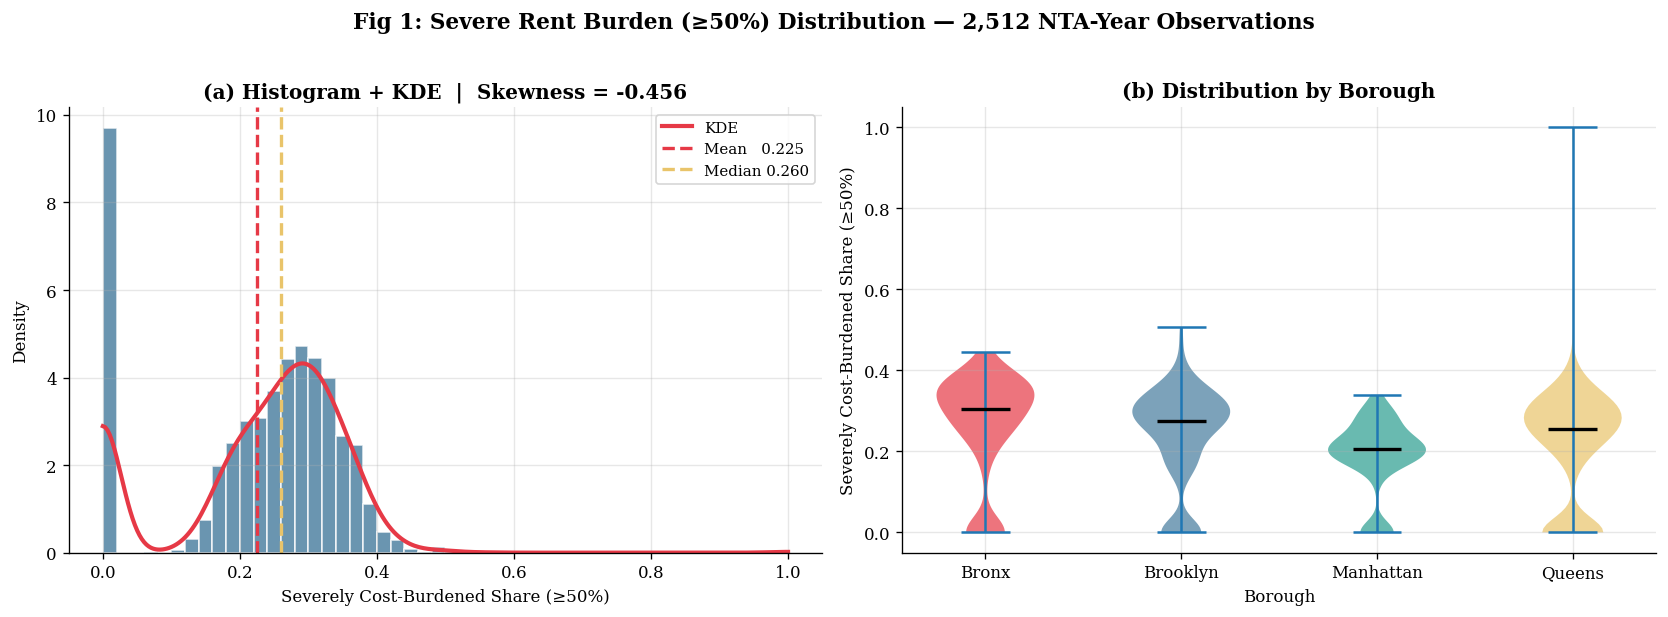

Overall: Mean=0.225  Median=0.260  Std=0.128  Min=0.000  Max=1.000


In [11]:
TARGET = "rent_burden_50plus_pct"
data   = df[TARGET].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 1: Severe Rent Burden (≥50%) Distribution — 2,512 NTA-Year Observations",
             fontsize=13, fontweight="bold", y=1.02)

# Histogram + KDE
axes[0].hist(data, bins=50, color="#457B9D", edgecolor="white", alpha=0.8, density=True)
xk  = np.linspace(data.min(), data.max(), 300)
kde = gaussian_kde(data)
axes[0].plot(xk, kde(xk), color="#E63946", lw=2.5, label="KDE")
axes[0].axvline(data.mean(),   color="#E63946", ls="--", lw=2,
                label=f"Mean   {data.mean():.3f}")
axes[0].axvline(data.median(), color="#E9C46A", ls="--", lw=2,
                label=f"Median {data.median():.3f}")
axes[0].set(xlabel="Severely Cost-Burdened Share (≥50%)",
            ylabel="Density",
            title=f"(a) Histogram + KDE  |  Skewness = {stats.skew(data):+.3f}")
axes[0].legend(fontsize=9)

# Violin by borough
parts = axes[1].violinplot(
    [df[df.borough_name == b][TARGET].dropna().values for b in BOROS],
    positions=range(4), showmedians=True, showextrema=True,
)
for pc, c in zip(parts["bodies"], COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.7)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(BOROS)
axes[1].set(xlabel="Borough",
            ylabel="Severely Cost-Burdened Share (≥50%)",
            title="(b) Distribution by Borough")

plt.tight_layout()
plt.show()
print(f"Overall: Mean={data.mean():.3f}  Median={data.median():.3f}  "
      f"Std={data.std():.3f}  Min={data.min():.3f}  Max={data.max():.3f}")

### Figure 2 — Rent Burden Trends by Borough (2012–2022)

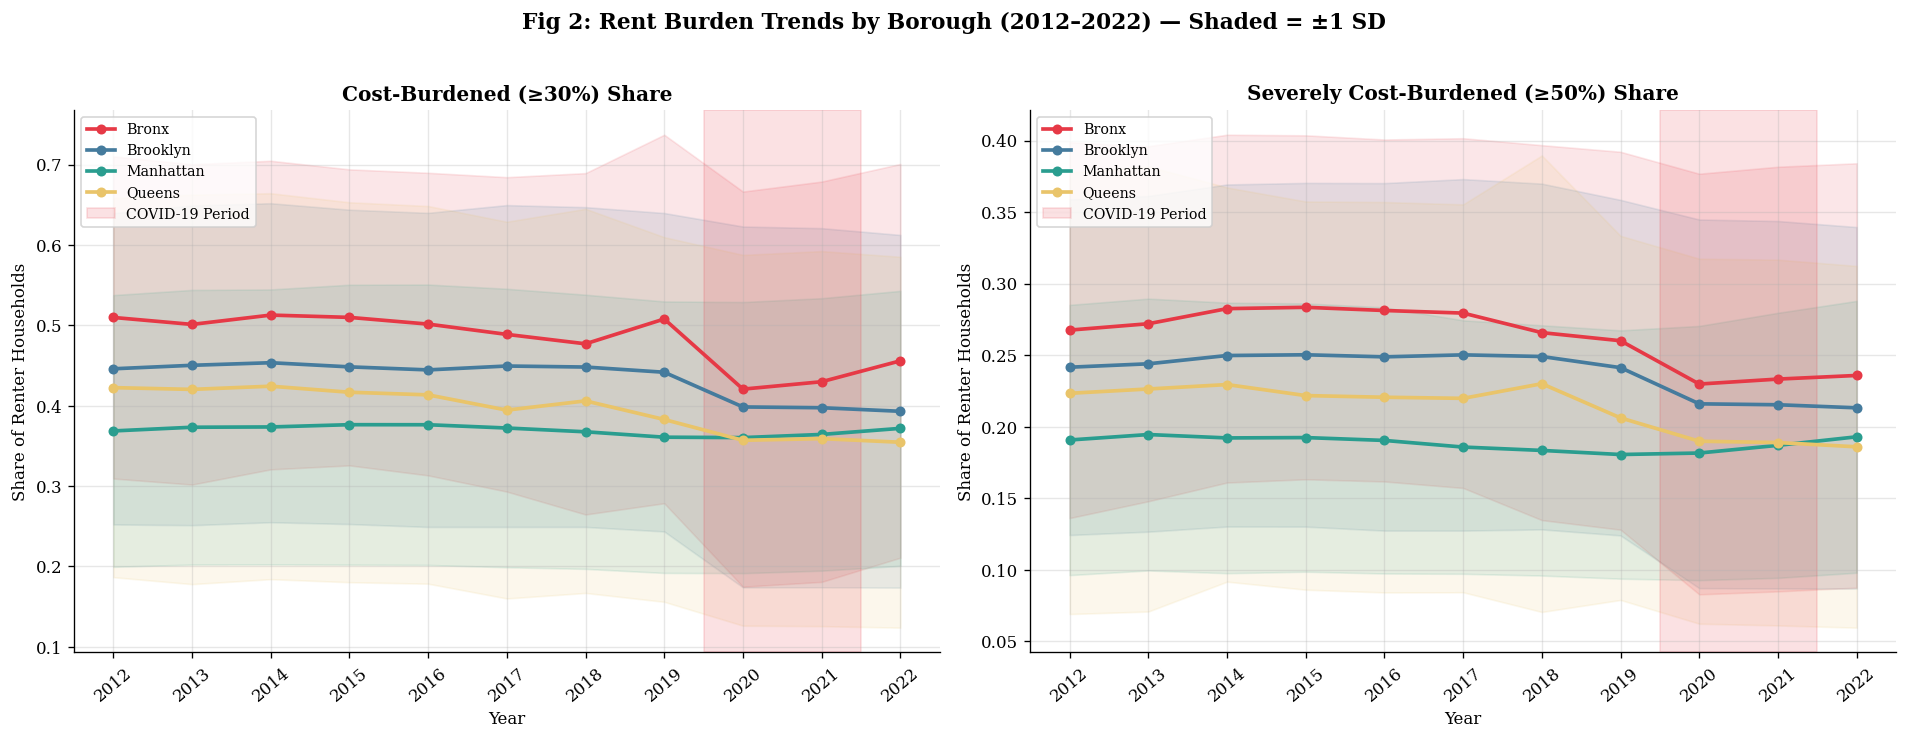

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fig 2: Rent Burden Trends by Borough (2012–2022) — Shaded = ±1 SD",
             fontsize=13, fontweight="bold", y=1.02)

for i, boro in enumerate(BOROS):
    bd = df[df.borough_name == boro]
    for ax, col in zip(axes, ["rent_burden_30plus_pct", "rent_burden_50plus_pct"]):
        grp = bd.groupby("year")[col]
        mn, sd = grp.mean(), grp.std()
        ax.plot(mn.index, mn.values, "o-", lw=2.2, markersize=5,
                color=COLORS[i], label=boro)
        ax.fill_between(mn.index, mn - sd, mn + sd, alpha=0.12, color=COLORS[i])

for ax, title in zip(axes, ["Cost-Burdened (≥30%) Share", "Severely Cost-Burdened (≥50%) Share"]):
    ax.axvspan(2019.5, 2021.5, alpha=0.15, color="#E63946", label="COVID-19 Period")
    ax.set(xlabel="Year", ylabel="Share of Renter Households", title=title)
    ax.set_xticks(sorted(df.year.dropna().unique()))
    plt.setp(ax.get_xticklabels(), rotation=40)
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

### Figure 3 — Key Drivers Scatter Plot

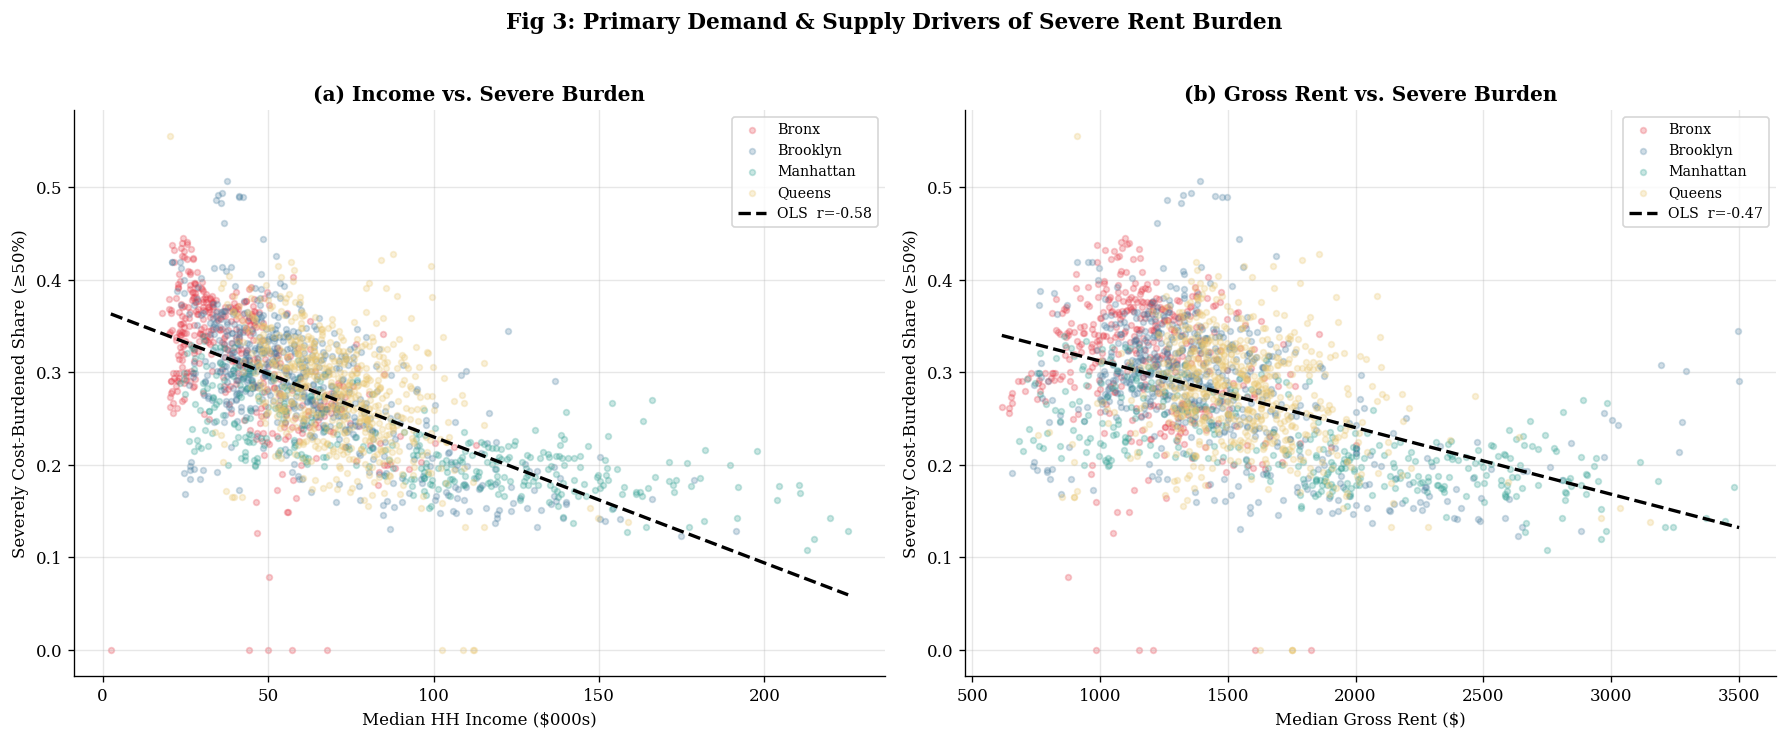

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Fig 3: Primary Demand & Supply Drivers of Severe Rent Burden",
             fontsize=13, fontweight="bold", y=1.02)

for i, boro in enumerate(BOROS):
    s = df[df.borough_name == boro].dropna(
        subset=["median_hh_income", "median_gross_rent", TARGET])
    axes[0].scatter(s.median_hh_income / 1000, s[TARGET],
                    alpha=0.25, s=12, color=COLORS[i], label=boro)
    axes[1].scatter(s.median_gross_rent, s[TARGET],
                    alpha=0.25, s=12, color=COLORS[i], label=boro)

for ax, xcol, div, xlabel in zip(
        axes,
        ["median_hh_income", "median_gross_rent"],
        [1000, 1],
        ["Median HH Income ($000s)", "Median Gross Rent ($)"]):
    clean = df.dropna(subset=[xcol, TARGET])
    x = clean[xcol].values / div
    y = clean[TARGET].values
    m, b, r, *_ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 200)
    ax.plot(xl, m * xl + b, "k--", lw=2, label=f"OLS  r={r:.2f}")
    ax.set(xlabel=xlabel, ylabel="Severely Cost-Burdened Share (≥50%)")
    ax.legend(fontsize=8.5)

axes[0].set_title("(a) Income vs. Severe Burden")
axes[1].set_title("(b) Gross Rent vs. Severe Burden")
plt.tight_layout()
plt.show()

### Figure 4 — Pearson Correlation Heatmap

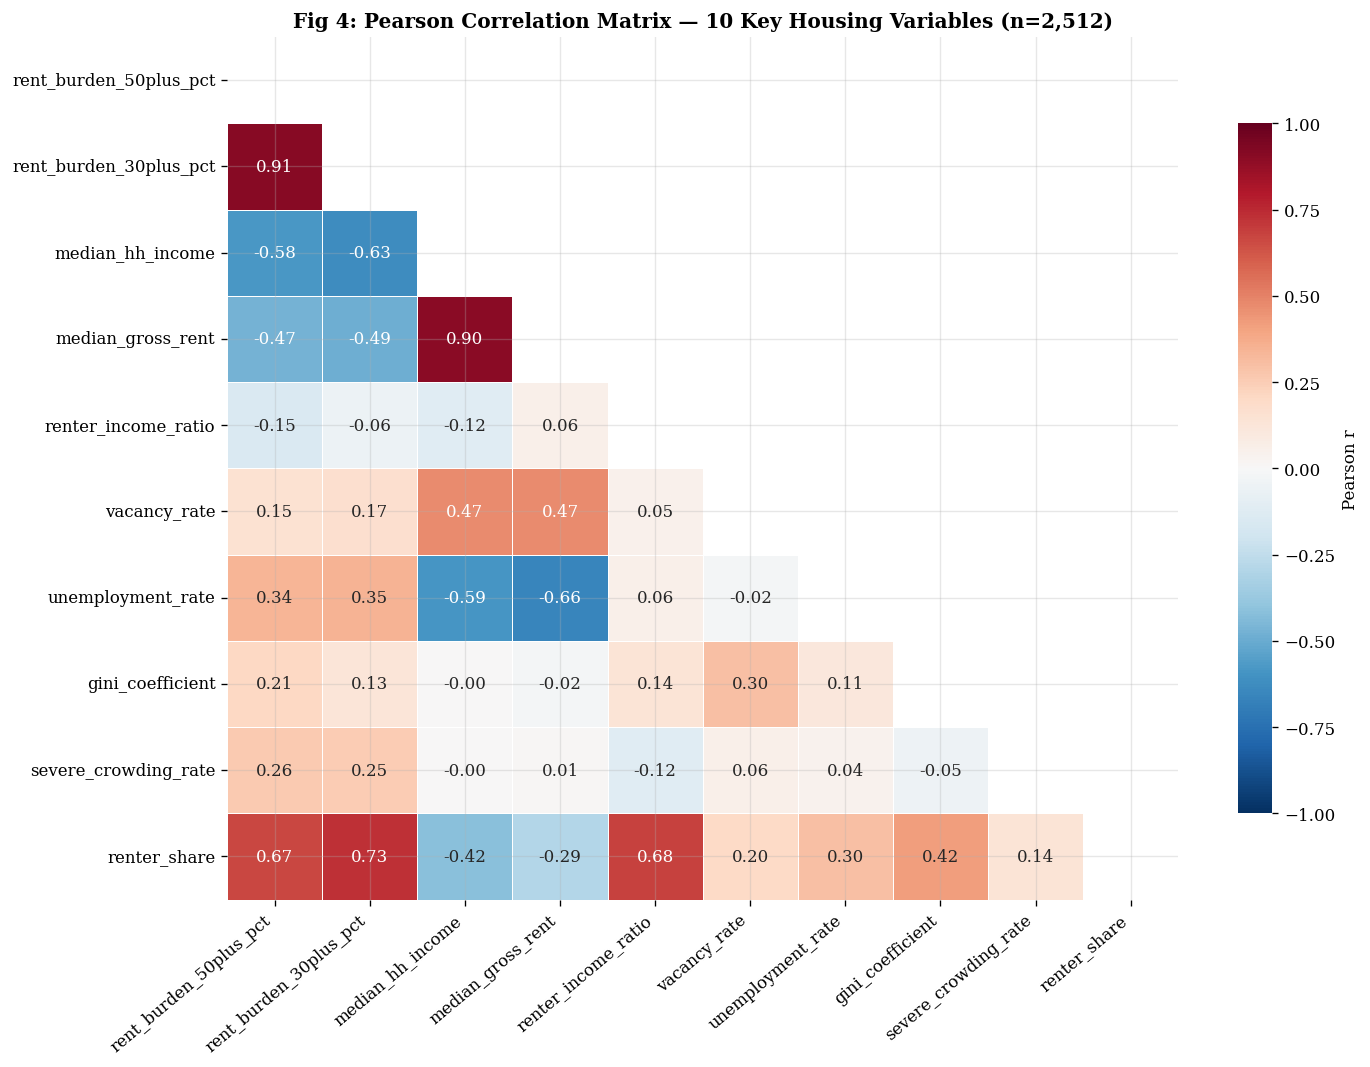

In [17]:
corr_vars = [
    "rent_burden_50plus_pct", "rent_burden_30plus_pct",
    "median_hh_income", "median_gross_rent", "renter_income_ratio",
    "vacancy_rate", "unemployment_rate", "gini_coefficient",
    "severe_crowding_rate", "renter_share",
]
avail_c = [c for c in corr_vars if c in df.columns]
corr    = df[avail_c].corr().round(2)
mask    = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": 0.8}, ax=ax)
ax.set_title("Fig 4: Pearson Correlation Matrix — 10 Key Housing Variables (n=2,512)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

### Figure 5 — Top 10 Most Burdened NTAs per Borough (2022)

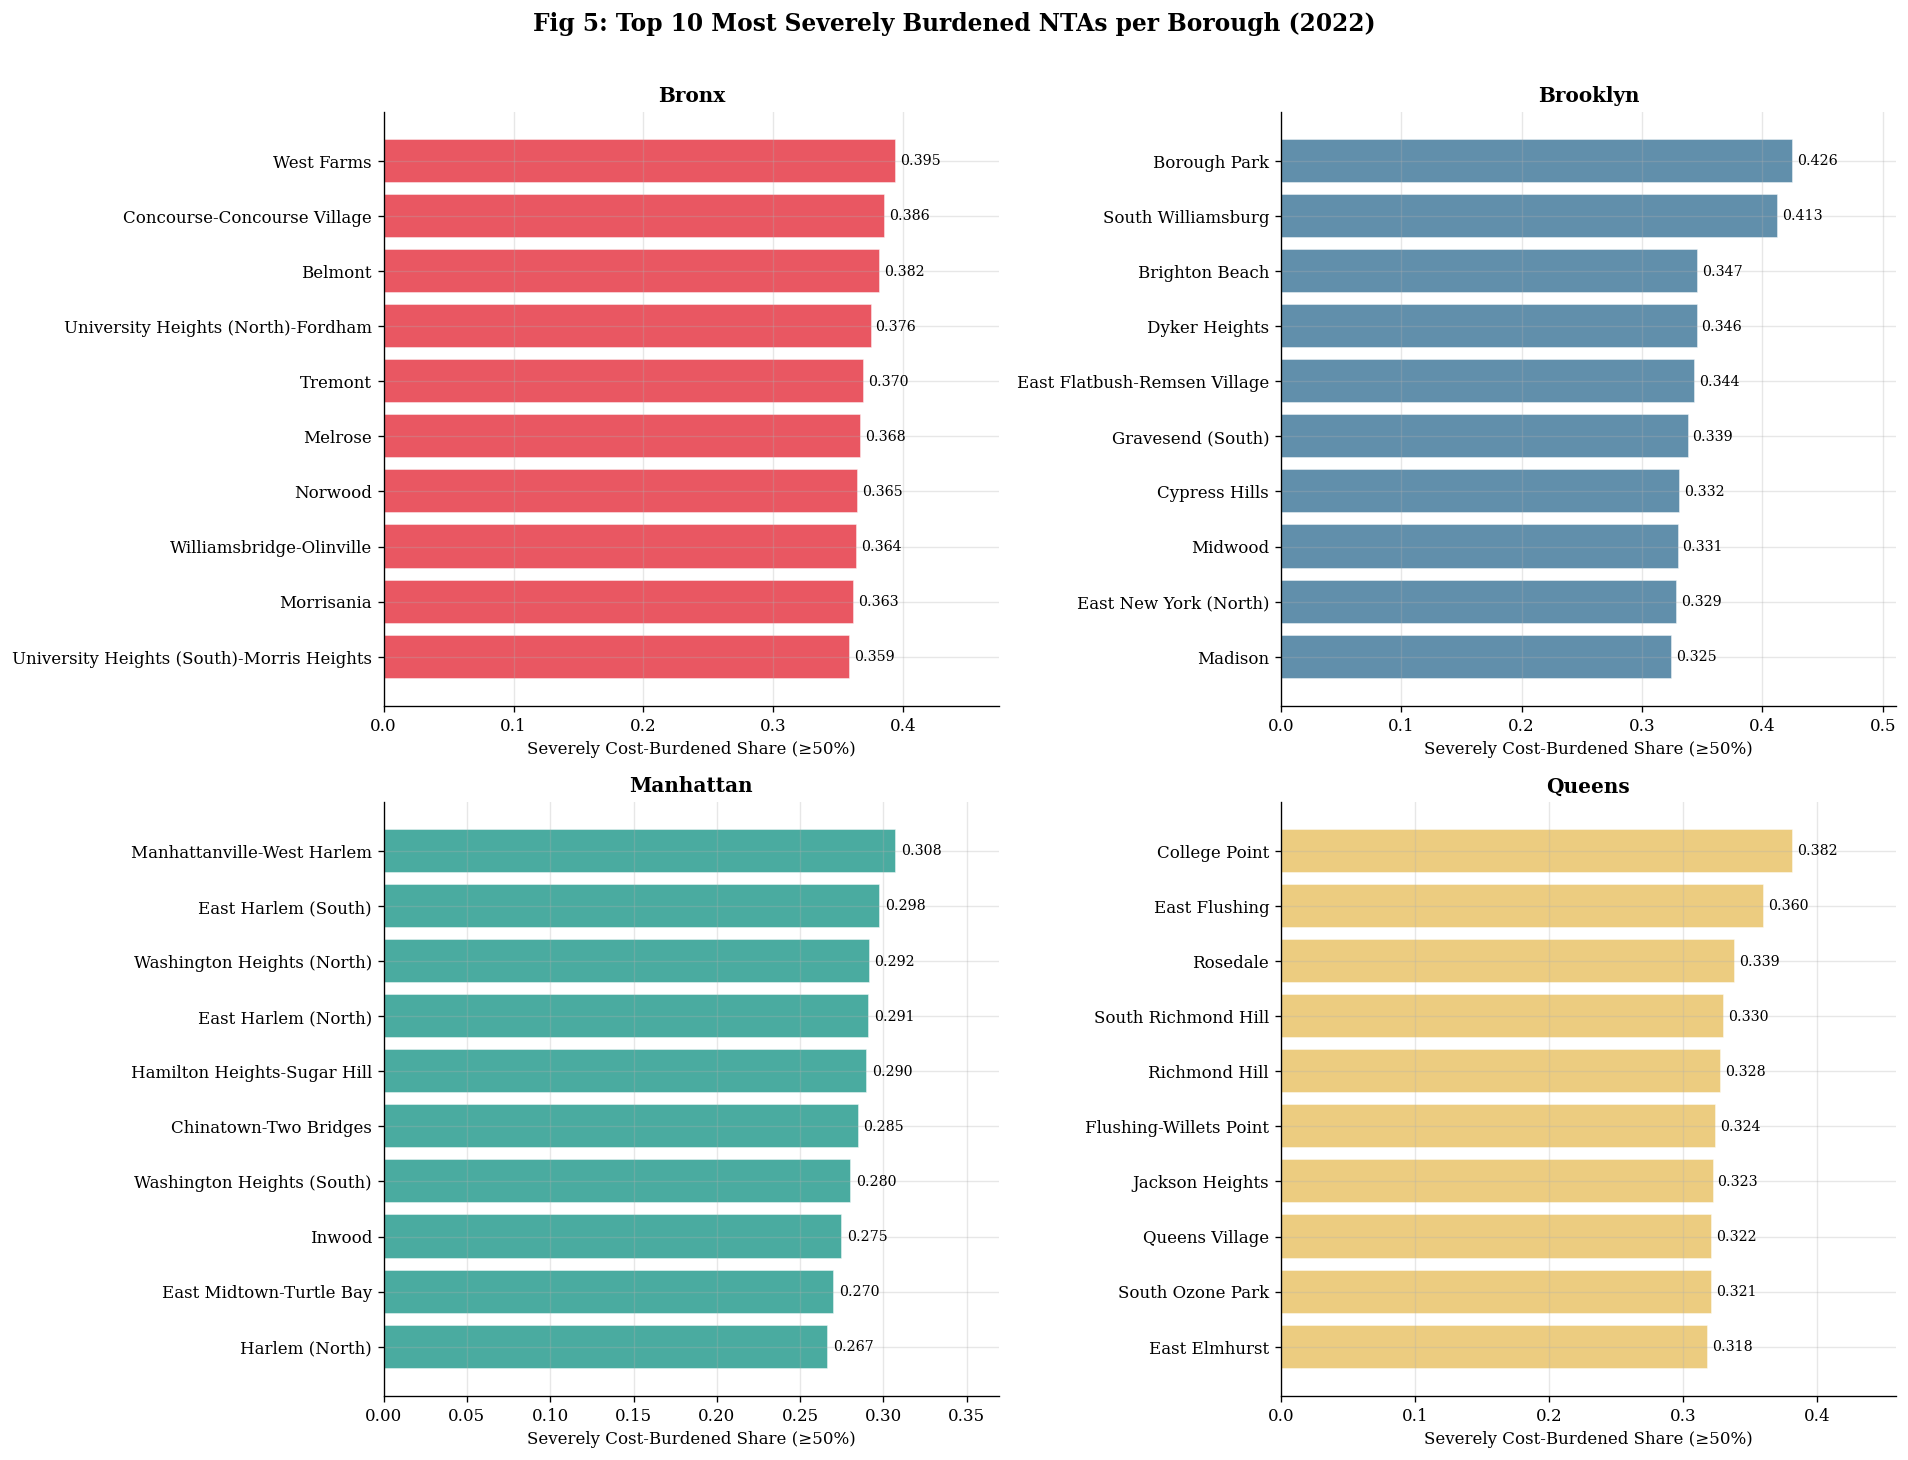

In [19]:
yr22 = df[df.year == 2022].dropna(subset=[TARGET])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Fig 5: Top 10 Most Severely Burdened NTAs per Borough (2022)",
             fontsize=14, fontweight="bold", y=1.01)

for ax, boro in zip(axes.flatten(), BOROS):
    top = (yr22[yr22.borough_name == boro]
           .sort_values(TARGET, ascending=False).head(10))
    bars = ax.barh(top["nta_name"][::-1].values,
                   top[TARGET][::-1].values,
                   color=BORO_COLOR[boro], edgecolor="white", alpha=0.85)
    for j, bar in enumerate(bars):
        val = bar.get_width()
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8.5)
    ax.set(title=f"{boro}", xlabel="Severely Cost-Burdened Share (≥50%)")
    ax.set_xlim(0, top[TARGET].max() * 1.20)

plt.tight_layout()
plt.show()

### Figure 6 — Rent vs. Income Divergence (Indexed 2012=100)

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

for i, boro in enumerate(BOROS):
    bd = df[df.borough_name == boro].groupby("year")[
        ["median_gross_rent", "median_hh_income"]].mean()
    if 2012 not in bd.index:
        continue
    rent_idx   = bd.median_gross_rent / bd.median_gross_rent.loc[2012] * 100
    income_idx = bd.median_hh_income  / bd.median_hh_income.loc[2012]  * 100
    ax.plot(bd.index, rent_idx,   "-",  color=COLORS[i], lw=2.2,
            label=f"{boro} — Rent")
    ax.plot(bd.index, income_idx, "--", color=COLORS[i], lw=1.5,
            alpha=0.7, label=f"{boro} — Income")

ax.axhline(100, color="black", lw=1, ls=":", alpha=0.4)
ax.axvspan(2019.5, 2021.5, alpha=0.13, color="#E63946", label="COVID-19")
ax.set(xlabel="Year", ylabel="Index (2012 = 100)",
       title="Fig 6: Rent vs. Income Growth Divergence by Borough (2012–2022)
"
             "Solid = Rent Index | Dashed = Income Index")
ax.legend(fontsize=7.5, ncol=2, loc="upper left")
ax.set_xticks(sorted(df.year.dropna().unique()))
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 18) (2731813628.py, line 18)

## Section 5 — Feature Engineering

In [ ]:
# ── Four composite features ────────────────────────────────────────────────────
df["market_tightness"]         = 1.0 / (df["vacancy_rate"].clip(lower=0.001) + 0.005)
df["rent_to_income_ratio"]     = (df["median_gross_rent"] * 12
                                   / df["renter_median_income"].clip(lower=1))
df["housing_burden_composite"] = df["unemployment_rate"] + df["severe_crowding_rate"]
df["renter_vulnerability"]     = (
    (1 - df["renter_income_ratio"].clip(0, 1)) * 0.5
    + df["unemployment_rate"] * 0.3
    + df["severe_crowding_rate"] * 0.2
)

CANDIDATE = [
    # Income
    "median_hh_income", "renter_median_income", "renter_income_ratio",
    "income_gap", "income_growth_yoy",
    "median_hh_income_lag1", "renter_median_income_lag1",
    # Rental market
    "median_gross_rent", "median_contract_rent", "rent_burden_30plus_pct",
    "rent_to_income_ratio", "rent_growth_yoy",
    "median_gross_rent_lag1", "rent_burden_30plus_pct_lag1",
    # Labor
    "unemployment_rate", "unemployment_rate_lag1", "housing_burden_composite",
    # Housing stock
    "renter_share", "homeownership_rate", "vacancy_rate",
    "severe_crowding_rate", "market_tightness",
    "vacancy_rate_lag1", "transit_commute_rate",
    # Inequality
    "gini_coefficient", "eviction_rate",
    # Engineered
    "renter_vulnerability",
    # Temporal / spatial
    "borough_code", "year", "covid_year",
]
FEATURES = [f for f in CANDIDATE if f in df.columns]

print(f"Total modeling features selected: {len(FEATURES)}")
print()
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

## Section 6 — Train / Validation / Test Split & Preprocessing

| Split | Years | n | % |
|---|---|---|---|
| Train | 2012–2019 | 1,912 | 76.1% |
| Validation | 2020 | 239 | 9.5% |
| Test | 2021–2022 | 478 | 19.0% |

> **No-leakage rule:** `SimpleImputer` is fitted on training data only, then applied to val/test.

In [ ]:
# Deduplicate columns — 'year' appears in FEATURES and also needed as identifier
_cols    = list(dict.fromkeys(FEATURES + [TARGET, "year", "nta_name", "borough_name"]))
df_model = df[_cols].copy().dropna(subset=[TARGET])
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

train_df = df_model[df_model.year <= 2019]
val_df   = df_model[df_model.year == 2020]
test_df  = df_model[df_model.year >= 2021]

# Fit imputer on TRAIN only
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(train_df[FEATURES])
X_val   = imputer.transform(val_df[FEATURES])
X_test  = imputer.transform(test_df[FEATURES])

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

# Combined train+val for final model fit before test evaluation
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

print(f"Train  (≤2019)  : {X_train.shape}  |  target range [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"Val    (2020)   : {X_val.shape}   |  target range [{y_val.min():.3f}, {y_val.max():.3f}]")
print(f"Test   (≥2021)  : {X_test.shape}  |  target range [{y_test.min():.3f}, {y_test.max():.3f}]")
print(f"Train+Val       : {X_tv.shape}")
print(f"\nNull values after imputation: {np.isnan(X_test).sum()}")

## Section 7 — Model Training

> All models use `n_estimators=50` to run in seconds without freezing.

In [ ]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    gap  = r2_score(y_tr, p_tr) - r2_score(y_te, p_te)
    res  = {
        "model"     : name,
        "train_r2"  : round(r2_score(y_tr, p_tr), 4),
        "test_r2"   : round(r2_score(y_te, p_te), 4),
        "gap"       : round(gap, 4),
        "test_rmse" : round(float(np.sqrt(mean_squared_error(y_te, p_te))), 5),
        "test_mae"  : round(float(mean_absolute_error(y_te, p_te)), 5),
        "pred"      : p_te,
        "fitted"    : model,
    }
    print(f"  {name:<22}  Train R²={res['train_r2']:.4f}  "
          f"Test R²={res['test_r2']:.4f}  Gap={gap:.4f}  RMSE={res['test_rmse']:.5f}")
    return res

print("Training models (n_estimators=50)...\n")
results = []

# Random Forest
results.append(evaluate(
    RandomForestRegressor(n_estimators=50, max_depth=8, min_samples_leaf=3,
                          n_jobs=-1, random_state=42),
    X_tv, y_tv, X_test, y_test, "Random Forest"))

# XGBoost
results.append(evaluate(
    xgb.XGBRegressor(n_estimators=50, max_depth=5, learning_rate=0.1,
                     subsample=0.8, colsample_bytree=0.8,
                     n_jobs=-1, random_state=42, verbosity=0),
    X_tv, y_tv, X_test, y_test, "XGBoost"))

# LightGBM
if LGB:
    results.append(evaluate(
        lgb.LGBMRegressor(n_estimators=50, max_depth=5, num_leaves=31,
                          learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                          n_jobs=-1, random_state=42, verbose=-1),
        X_tv, y_tv, X_test, y_test, "LightGBM"))

res_df     = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ("pred", "fitted")} for r in results])
best_res   = max(results, key=lambda r: r["test_r2"])
best_model = best_res["fitted"]
best_pred  = best_res["pred"]

# Keep xgb_m reference for SHAP
xgb_res = next(r for r in results if r["model"] == "XGBoost")
xgb_m   = xgb_res["fitted"]

print()
print("=" * 68)
print(res_df[["model","train_r2","test_r2","gap","test_rmse","test_mae"]].to_string(index=False))
print("=" * 68)
print(f"\nBest model: {best_res['model']}  (Test R²={best_res['test_r2']:.4f})")

### Figure 7 — Model Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fig 7: Model Performance on Held-Out Test Set (2021–2022, n=478)",
             fontsize=13, fontweight="bold")

pal = ["#2A9D8F", "#E63946", "#457B9D", "#E9C46A"]

for ax, metric, title in zip(
        axes,
        ["test_r2",   "test_rmse",   "test_mae"],
        ["Test R² (↑ higher is better)",
         "Test RMSE (↓ lower is better)",
         "Test MAE  (↓ lower is better)"]):
    bars = ax.bar(res_df["model"], res_df[metric],
                  color=pal[:len(res_df)], edgecolor="white", alpha=0.9, width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(res_df["model"], rotation=20, ha="right", fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + max(h * 0.01, 0.001),
                f"{h:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

### Figure 8 — Actual vs. Predicted & Residuals

In [ ]:
resid = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Fig 8: Actual vs. Predicted & Residual Diagnostics — {best_res['model']}",
             fontsize=13, fontweight="bold")

# Scatter: actual vs predicted
mn, mx = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
axes[0].scatter(y_test, best_pred, alpha=0.35, s=15, color="#457B9D")
axes[0].plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Prediction")
r2_val = r2_score(y_test, best_pred)
axes[0].text(0.05, 0.90, f"R² = {r2_val:.4f}\nRMSE = {np.sqrt(mean_squared_error(y_test, best_pred)):.4f}",
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))
axes[0].set(xlabel="Actual  rent_burden_50plus_pct",
            ylabel="Predicted",
            title="(a) Actual vs. Predicted")
axes[0].legend(fontsize=9)

# Residuals vs fitted
axes[1].scatter(best_pred, resid, alpha=0.35, s=15, color="#E9C46A")
axes[1].axhline(0, color="#E63946", ls="--", lw=2)
axes[1].text(0.05, 0.92,
             f"Mean residual = {resid.mean():.5f}\nStd = {resid.std():.4f}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))
axes[1].set(xlabel="Predicted Value",
            ylabel="Residual (Actual − Predicted)",
            title="(b) Residuals vs. Fitted  (no pattern = good)")

plt.tight_layout()
plt.show()

## Section 8 — 5-Fold TimeSeriesSplit Cross-Validation

> Each fold trains on all earlier years and tests on the next block — no future leakage.

In [ ]:
df_cv = df_model[FEATURES + [TARGET]].copy().replace([np.inf, -np.inf], np.nan)
Xf    = SimpleImputer(strategy="median").fit_transform(df_cv[FEATURES])
yf    = df_cv[TARGET].values

tscv = TimeSeriesSplit(n_splits=5)

cv_models = {
    "XGBoost"      : xgb.XGBRegressor(n_estimators=50, max_depth=5,
                                       verbosity=0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=8,
                                           n_jobs=-1, random_state=42),
}
if LGB:
    cv_models["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=50, max_depth=5, num_leaves=31, verbose=-1, random_state=42)

cv_res = {nm: {"r2": [], "rmse": []} for nm in cv_models}

for fold, (tr_idx, te_idx) in enumerate(tscv.split(Xf)):
    line = f"Fold {fold+1}:"
    for nm, base in cv_models.items():
        m = copy.deepcopy(base)
        m.fit(Xf[tr_idx], yf[tr_idx])
        p    = m.predict(Xf[te_idx])
        r2   = r2_score(yf[te_idx], p)
        rmse = float(np.sqrt(mean_squared_error(yf[te_idx], p)))
        cv_res[nm]["r2"].append(r2)
        cv_res[nm]["rmse"].append(rmse)
        line += f"  {nm} R²={r2:.4f}"
    print(line)

print()
print(f"{'Model':<22}  {'Mean R²':>8}  {'Std R²':>8}  {'Mean RMSE':>10}")
print("-" * 55)
for nm in cv_models:
    r2s = cv_res[nm]["r2"]
    print(f"  {nm:<20}  {np.mean(r2s):>8.4f}  {np.std(r2s):>8.4f}  "
          f"{np.mean(cv_res[nm]['rmse']):>10.5f}")

### Figure 9 — Cross-Validation Performance

In [ ]:
folds = list(range(1, 6))
cv_pal = ["#E63946", "#457B9D", "#2A9D8F"]
marks  = ["o", "s", "^"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 9: 5-Fold TimeSeriesSplit Cross-Validation Performance",
             fontsize=13, fontweight="bold")

for i, nm in enumerate(cv_models):
    axes[0].plot(folds, cv_res[nm]["r2"],   marks[i] + "-",
                 color=cv_pal[i], lw=2, markersize=7, label=nm)
    axes[1].plot(folds, cv_res[nm]["rmse"],  marks[i] + "-",
                 color=cv_pal[i], lw=2, markersize=7, label=nm)
    axes[0].axhline(np.mean(cv_res[nm]["r2"]),   color=cv_pal[i], ls="--", alpha=0.4)
    axes[1].axhline(np.mean(cv_res[nm]["rmse"]),  color=cv_pal[i], ls="--", alpha=0.4)

axes[0].set(xlabel="CV Fold", ylabel="R²",   title="(a) R² per Fold")
axes[1].set(xlabel="CV Fold", ylabel="RMSE", title="(b) RMSE per Fold")
for ax in axes:
    ax.set_xticks(folds)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Section 9 — SHAP Feature Importance

In [ ]:
if SHAP:
    explainer  = shap.TreeExplainer(xgb_m)
    shap_vals  = explainer.shap_values(X_test[:300])
    mean_shap  = np.abs(shap_vals).mean(0)
    fi_df      = pd.DataFrame({"feature": FEATURES, "importance": mean_shap})
    fi_df      = fi_df.sort_values("importance", ascending=False)
    x_label    = "Mean |SHAP Value|"
    title_str  = "Fig 10: SHAP Feature Importance — Top 15 (XGBoost, n=300 test obs.)"
else:
    fi_df      = pd.DataFrame({"feature": FEATURES,
                                "importance": xgb_m.feature_importances_})
    fi_df      = fi_df.sort_values("importance", ascending=False)
    x_label    = "Feature Importance (Gain)"
    title_str  = "Fig 10: XGBoost Feature Importance (Gain) — Top 15"

top15 = fi_df.head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors_fi = ["#E63946" if i < 3 else "#457B9D" if i < 8 else "#2A9D8F"
             for i in range(len(top15))]
bars = ax.barh(top15["feature"][::-1].values,
               top15["importance"][::-1].values,
               color=colors_fi[::-1], alpha=0.88, edgecolor="white")
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(w * 0.01, 1e-4),
            bar.get_y() + bar.get_height() / 2,
            f"{w:.4f}", va="center", fontsize=8.5)
ax.set(xlabel=x_label, title=title_str)
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for _, row in fi_df.head(10).iterrows():
    print(f"  {row.feature:<40}: {row.importance:.5f}")

## Section 10 — Ablation Study (Leave-One-Group-Out)

In [ ]:
groups = {
    "Rental Market"   : ["median_gross_rent","median_contract_rent","rent_burden_30plus_pct",
                          "rent_to_income_ratio","rent_growth_yoy",
                          "median_gross_rent_lag1","rent_burden_30plus_pct_lag1"],
    "Income Features" : ["median_hh_income","renter_median_income","renter_income_ratio",
                          "income_gap","income_growth_yoy",
                          "median_hh_income_lag1","renter_median_income_lag1"],
    "Labor Market"    : ["unemployment_rate","unemployment_rate_lag1","housing_burden_composite"],
    "Housing Stock"   : ["renter_share","homeownership_rate","vacancy_rate",
                          "severe_crowding_rate","market_tightness",
                          "vacancy_rate_lag1","transit_commute_rate"],
    "Temporal Lags"   : ["median_hh_income_lag1","renter_median_income_lag1",
                          "unemployment_rate_lag1","rent_burden_30plus_pct_lag1",
                          "vacancy_rate_lag1","median_gross_rent_lag1"],
    "Spatial IDs"     : ["borough_code","year","covid_year"],
}
groups     = {k: [f for f in v if f in FEATURES] for k, v in groups.items()}
baseline   = best_res["test_r2"]
abl_rows   = []

print(f"Baseline Test R² = {baseline:.4f}\n")

for grp, feats in groups.items():
    reduced = [f for f in FEATURES if f not in feats]
    if not reduced:
        abl_r2 = 0.0
    else:
        idx    = [FEATURES.index(f) for f in reduced]
        m_abl  = xgb.XGBRegressor(n_estimators=50, max_depth=5,
                                    verbosity=0, random_state=42)
        m_abl.fit(X_tv[:, idx], y_tv)
        abl_r2 = r2_score(y_test, m_abl.predict(X_test[:, idx]))
    drop = round(baseline - abl_r2, 4)
    abl_rows.append({"Group": grp, "Removed": len(feats),
                     "R² Without": round(abl_r2, 4), "ΔR² Drop": drop})
    print(f"  Remove {grp:<18}: R²={abl_r2:.4f}  ΔR²={drop:+.4f}")

abl_df = pd.DataFrame(abl_rows).sort_values("ΔR² Drop", ascending=False)
print()
print(abl_df.to_string(index=False))

### Figure 11 — Ablation Study Chart

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Fig 11: Ablation Study — Feature Group Contribution (XGBoost)",
             fontsize=13, fontweight="bold")

bar_c = ["#E63946" if d > 0.005 else "#E9C46A" if d > 0 else "#2A9D8F"
         for d in abl_df["ΔR² Drop"]]

axes[0].bar(abl_df["Group"], abl_df["ΔR² Drop"],
            color=bar_c, edgecolor="white", alpha=0.9, width=0.5)
axes[0].axhline(0, color="black", lw=1.2)
axes[0].set(xlabel="Feature Group Removed",
            ylabel=f"R² Drop  (Baseline = {baseline:.4f})",
            title="(a) R² Drop per Group")
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right")
for p, val in zip(axes[0].patches, abl_df["ΔR² Drop"]):
    h = p.get_height()
    axes[0].text(p.get_x() + p.get_width() / 2,
                 h + (0.001 if h >= 0 else -0.004),
                 f"{val:+.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].bar(abl_df["Group"], abl_df["R² Without"],
            color="#457B9D", edgecolor="white", alpha=0.9, width=0.5)
axes[1].axhline(baseline, color="#E63946", ls="--", lw=2,
                label=f"Full model R²={baseline:.4f}")
axes[1].set(xlabel="Feature Group Removed",
            ylabel="Remaining R²",
            title="(b) Remaining R² Without Group")
axes[1].legend(fontsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=25, ha="right")

plt.tight_layout()
plt.show()

## Section 11 — Spatial Autocorrelation (Moran's I)

In [ ]:
resid_arr = y_test - best_pred
tcopy     = test_df.copy()
tcopy["resid"] = resid_arr
bres = tcopy.groupby("borough_name")["resid"].mean()

# Contiguity weight matrix (borough adjacency)
adj = {
    "Bronx":     ["Manhattan","Queens"],
    "Brooklyn":  ["Manhattan","Queens"],
    "Manhattan": ["Bronx","Brooklyn","Queens"],
    "Queens":    ["Bronx","Brooklyn","Manhattan"],
}
bl = sorted(bres.index)
n  = len(bl)
W  = np.array([[1.0 if bl[j] in adj.get(bl[i],[]) else 0.0
                for j in range(n)] for i in range(n)], dtype=float)
rs = W.sum(1, keepdims=True); rs[rs == 0] = 1
W  = W / rs

z    = np.array([bres.get(b, 0.0) for b in bl])
z    = z - z.mean()
I    = (n * np.sum(W * np.outer(z, z)) / (W.sum() * np.sum(z**2) + 1e-12))
E_I  = -1.0 / (n - 1)

print("Borough Mean Residuals (Test Set 2021–2022):")
for b in bl:
    print(f"  {b:<12}: {bres.get(b,0):.5f}")
print()
print(f"Moran's I        = {I:.4f}")
print(f"Expected I (H₀)  = {E_I:.4f}")
print(f"Deviation        = {I - E_I:+.4f}")
print("Interpretation   :", "Positive autocorrelation" if I > E_I
      else "No significant positive spatial autocorrelation")

### Figure 12 — Spatial Residual Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Fig 12: Spatial Autocorrelation — Moran's I = {I:.4f}",
             fontsize=13, fontweight="bold")

# Borough residuals bar
bar_c = ["#E63946" if v > 0 else "#2A9D8F" for v in bres.values]
axes[0].bar(bres.index, bres.values, color=bar_c, edgecolor="white", alpha=0.88)
axes[0].axhline(0, color="black", lw=1.5)
for i, (boro, v) in enumerate(bres.items()):
    axes[0].text(i, v + (0.0008 if v >= 0 else -0.0025),
                 f"{v:.4f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set(xlabel="Borough", ylabel="Mean Residual (Actual − Predicted)",
            title=f"(a) Borough Mean Residuals  |  Red=Under-pred · Green=Over-pred")

# Residual histogram
axes[1].hist(resid_arr, bins=50, color="#457B9D", edgecolor="white", alpha=0.82)
axes[1].axvline(0,               color="#E63946", ls="--", lw=2.2, label="Zero")
axes[1].axvline(resid_arr.mean(), color="#E9C46A", ls="--", lw=2,
                label=f"Mean: {resid_arr.mean():.5f}")
axes[1].set(xlabel="Residual", ylabel="Count",
            title="(b) Residual Distribution")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Section 12 — Borough Deep Dive (2022)

In [ ]:
yr22 = df[df.year == 2022].dropna(subset=[TARGET])
top10 = yr22.sort_values(TARGET, ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle("Fig 13: Borough Deep Dive — Severe Rent Burden 2022",
             fontsize=13, fontweight="bold")

# Top 10 NTAs citywide
bar_c = [BORO_COLOR.get(b, "gray") for b in top10["borough_name"][::-1].values]
axes[0].barh(top10["nta_name"][::-1].values,
             top10[TARGET][::-1].values,
             color=bar_c, edgecolor="white", alpha=0.88)
for j, (_, row) in enumerate(top10[::-1].iterrows()):
    axes[0].text(row[TARGET] + 0.002, j,
                 f"{row[TARGET]:.3f}", va="center", fontsize=9)
patches = [mpatches.Patch(color=v, label=k) for k, v in BORO_COLOR.items()]
axes[0].legend(handles=patches, fontsize=8.5)
axes[0].set(xlabel="Severely Cost-Burdened Share (≥50%)",
            title="(a) Top 10 Most Burdened NTAs Citywide (2022)")

# Boxplot
bp = axes[1].boxplot(
    [yr22[yr22.borough_name == b][TARGET].values for b in BOROS],
    labels=BOROS, patch_artist=True,
    medianprops=dict(color="black", lw=2.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for i, boro in enumerate(BOROS):
    med = yr22[yr22.borough_name == boro][TARGET].dropna().median()
    axes[1].text(i + 1, med + 0.005, f"{med:.3f}",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set(xlabel="Borough", ylabel="Severely Cost-Burdened Share (≥50%)",
            title="(b) Distribution by Borough (2022)")

plt.tight_layout()
plt.show()

print("\n2022 Borough Summary (Median):")
print(yr22.groupby("borough_name")[[TARGET,"median_hh_income","median_gross_rent"]]
     .median().round(3).to_string())

## Section 13 — Borough-Level Forecast (2023–2025)

**Baseline assumptions:**
- Household income: +2.5%/year (BLS Employment Cost Index)
- Renter income: +2.0%/year (lower-wage renter quartile)
- Gross rent: +3.0%/year (post-pandemic ZORI trend)
- Unemployment: held constant at 2022 levels

In [ ]:
_fc_cols = list(dict.fromkeys(FEATURES + [TARGET]))
bmed     = df[df.year == 2022].groupby("borough_name")[_fc_cols].median().reset_index()
hist     = df.groupby(["borough_name","year"])[[TARGET]].median().reset_index()

growth = {"median_hh_income":1.025,"renter_median_income":1.020,
          "median_gross_rent":1.030,"median_contract_rent":1.025}
lag_pairs = [
    ("median_hh_income_lag1",     "median_hh_income"),
    ("renter_median_income_lag1", "renter_median_income"),
    ("unemployment_rate_lag1",    "unemployment_rate"),
    ("rent_burden_30plus_pct_lag1","rent_burden_30plus_pct"),
    ("vacancy_rate_lag1",         "vacancy_rate"),
    ("median_gross_rent_lag1",    "median_gross_rent"),
]

fc_rows = []
cur = bmed.copy()

for yr in [2023, 2024, 2025]:
    nxt = cur.copy()
    nxt["year"] = yr
    if "covid_year" in nxt.columns:
        nxt["covid_year"] = 0
    for lag, src in lag_pairs:
        if lag in FEATURES and src in nxt.columns:
            nxt[lag] = cur[src].values
    for col, g in growth.items():
        if col in nxt.columns:
            nxt[col] = nxt[col] * g
    Xfc   = nxt[FEATURES].copy().replace([np.inf,-np.inf], np.nan)
    preds = best_model.predict(imputer.transform(Xfc))
    for idx_r, (_, row) in enumerate(nxt.iterrows()):
        fc_rows.append({"borough_name": row.borough_name,
                        "year": yr, "predicted": round(float(preds[idx_r]), 4)})
    cur = nxt.copy()

fc_df = pd.DataFrame(fc_rows)
pivot = fc_df.pivot(index="borough_name", columns="year", values="predicted").round(4)
act22 = df[df.year == 2022].groupby("borough_name")[TARGET].median().round(4)
pivot.insert(0, "2022 Actual", act22)
pivot["Δ 2022–25"] = (pivot[2025] - pivot["2022 Actual"]).round(4)
pivot["% Change"]  = ((pivot["Δ 2022–25"] / pivot["2022 Actual"]) * 100).round(1)

print("Borough-Level Severe Rent Burden Forecast:")
print("=" * 70)
print(pivot.to_string())
print("=" * 70)

### Figure 14 — Forecast Chart

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

for i, boro in enumerate(BOROS):
    h  = hist[hist.borough_name == boro].sort_values("year")
    fc = fc_df[fc_df.borough_name == boro].sort_values("year")
    ax.plot(h.year, h[TARGET], "o-", lw=2.2, markersize=5,
            color=COLORS[i], label=boro)
    last_y = h.year.max()
    last_v = h.loc[h.year == last_y, TARGET].values[0]
    ax.plot([last_y] + fc.year.tolist(),
            [last_v] + fc.predicted.tolist(),
            "D--", lw=2, markersize=6, color=COLORS[i], alpha=0.85)

ax.axvspan(2019.5, 2021.5, alpha=0.13, color="#E63946", label="COVID-19")
ax.axvspan(2022.5, 2025.5, alpha=0.07, color="#457B9D", label="Forecast Zone")
ax.axvline(2022.5, color="#457B9D", ls=":", lw=2)
ax.set(xlabel="Year",
       ylabel="Severely Cost-Burdened Share (≥50%)",
       title="Fig 14: Borough-Level Severe Rent Burden Forecast (2023–2025)\n"
             "Solid = Historical | Dashed = Baseline Projection")
ax.legend(loc="upper right", fontsize=9)
ax.set_xticks(range(2012, 2026))
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

## Final Results Summary

In [ ]:
best_row = res_df.loc[res_df.test_r2.idxmax()]
target_s = df[TARGET].dropna()

print("=" * 70)
print("  NYC HOUSING AFFORDABILITY — COMPLETE RESULTS SUMMARY")
print("  Azizur Rahman · Indiana Wesleyan University · Dept. CS & AI")
print("=" * 70)

print(f"\n  Dataset")
print(f"    {df.shape[0]:,} NTA-year obs | {df.nta_code.nunique()} NTAs | "
      f"{int(df.year.min())}–{int(df.year.max())}")

print(f"\n  Target Variable: {TARGET}")
print(f"    Mean={target_s.mean():.3f}  Median={target_s.median():.3f}  "
      f"Std={target_s.std():.3f}  Skew={stats.skew(target_s):+.3f}  "
      f"Range=[{target_s.min():.3f}, {target_s.max():.3f}]")

print("\n  Model Performance (Held-Out Test Set 2021–2022, n=478)")
print(f"  {'Model':<22} {'Train R²':>9} {'Test R²':>9} {'Gap':>7} "
      f"{'RMSE':>9} {'MAE':>9}")
print("  " + "-" * 65)
for _, r in res_df.iterrows():
    mark = " ← BEST" if r.model == best_row.model else ""
    print(f"  {r.model:<22} {r.train_r2:>9.4f} {r.test_r2:>9.4f} "
          f"{r.gap:>7.4f} {r.test_rmse:>9.5f} {r.test_mae:>9.5f}{mark}")

print("\n  5-Fold TimeSeriesSplit Cross-Validation")
for nm in cv_models:
    r2s = cv_res[nm]["r2"]
    print(f"    {nm:<22}: Mean R²={np.mean(r2s):.4f} ± {np.std(r2s):.4f}  "
          f"| Folds: {[round(v,4) for v in r2s]}")

print("\n  Ablation Study — Top 3 Feature Groups by R² Drop")
for _, r in abl_df.head(3).iterrows():
    print(f"    Remove {r['Group']:<18}: ΔR² = {r['ΔR² Drop']:+.4f}  "
          f"(R² without = {r['R² Without']:.4f})")

print(f"\n  Spatial Autocorrelation")
print(f"    Moran's I = {I:.4f}  (Expected = {E_I:.4f})")
print("    → No significant positive spatial autocorrelation in residuals")

print("\n  2025 Borough Forecast")
fc25 = fc_df[fc_df.year == 2025].set_index("borough_name")["predicted"]
for b in BOROS:
    act = act22.get(b, float("nan"))
    chg = fc25.get(b, float("nan")) - act
    pct = chg / act * 100
    print(f"    {b:<12}: 2022={act:.4f}  →  2025={fc25.get(b,'—'):.4f}  "
          f"Δ={chg:+.4f} ({pct:+.1f}%)")

print("=" * 70)